# [실습 13-1] Gymnasium FrozenLake로 Q-러닝 구현

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 40~50분 (CPU 충분) |
| 본문 연계 | 13.3 Q-러닝 (그리드월드와 동일 구조) |
| 선수 실습 | 없음 (부록 B.3 권장) |
| 준비 | 부록 B.1·B.3 참고 |

본문 그리드월드와 같은 구조의 얼음 호수(4×4)에서 에이전트가
**시행착오만으로** 길을 배우는 것을 확인한다 — 갱신식 한 줄이
학습의 전부다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 세 줄의 주석을 해제하고 실행)
# !git clone https://github.com/tbgoodlife/ai-labs.git
# %cd ai-labs
# !pip -q install gymnasium
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch13/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from utils import plot_style, viz

plot_style.apply()              # 도해 스타일 킷 적용
print("Python", platform.python_version())
print("NumPy", np.__version__,
      "/ Gymnasium", gym.__version__)

Python 3.12.6
NumPy 2.4.6 / Gymnasium 1.3.0


### [셀 1] 환경 생성 — 본문 그리드월드가 코드로 📖

In [2]:
env = gym.make("FrozenLake-v1", map_name="4x4",
               is_slippery=False)   # 결정적 환경(기본)

desc = env.unwrapped.desc.astype(str)
print("지도 (S=출발, F=얼음, H=구멍, G=목표)")
for row in desc:
    print(" ".join(row))
print(f"\n상태 {env.observation_space.n}개 × "
      f"행동 {env.action_space.n}개"
      f" (0=왼쪽, 1=아래, 2=오른쪽, 3=위)")

지도 (S=출발, F=얼음, H=구멍, G=목표)
S F F F
F H F H
F F F H
H F F G

상태 16개 × 행동 4개 (0=왼쪽, 1=아래, 2=오른쪽, 3=위)


**핵심 포인트**
- 본문 13.2의 그리드월드 도해와 **같은 구조**다 — 상태 16개(칸), 행동 4개(방향), 보상은 목표 도달 시 1.
- `is_slippery=False`는 "명령대로 움직이는" 결정적 환경 — 손계산과 코드를 잇기 위한 설정이다. 미끄러운(확률적) 버전은 [심화 2]에서 다룬다.

기대 출력: 4×4 지도, 상태 16개 × 행동 4개

### [셀 2] Q-테이블과 갱신 1스텝 — 손계산의 재현 📖

> ⚠️ **역반영 표기**: 아래 α·γ와 예시 전이는 설계 기준값(α=0.1, γ=0.9)이다.
> 본문 13.3.2 손계산 원고가 확정되면 동일 수치인지 대조한다(@dev-live).

In [3]:
Q = np.zeros((16, 4))           # 빈 수첩에서 시작
alpha, gamma = 0.1, 0.9         # 안전한 시작값

# 목표 바로 왼쪽 칸(상태 14)에서 오른쪽(행동 2)으로
# 한 걸음 — 보상 1을 받는 가장 단순한 갱신을 재현한다
s, a, r, s_next = 14, 2, 1.0, 15
target = r + gamma * Q[s_next].max()   # 목표값
Q[s, a] += alpha * (target - Q[s, a])  # 갱신식(13.3.2)

print(f"목표값 = {r} + {gamma}×{0.0} = {target}")
print(f"Q[14, 오른쪽] : 0.0 → {Q[14, 2]:.3f}")

목표값 = 1.0 + 0.9×0.0 = 1.0
Q[14, 오른쪽] : 0.0 → 0.100


**핵심 포인트**
- 갱신식 한 줄 `Q += α(목표 − 현재)`가 Q-러닝의 전부다 — 받은 보상(r)과 다음 칸의 최선 전망(γ·max Q)을 합친 "목표값" 쪽으로 α만큼 다가간다.
- 첫 갱신에서 0.1만 이동한다(α=0.1) — 한 번의 경험을 다 믿지 않는 조심성이다.

기대 출력: `Q[14, 오른쪽] : 0.0 → 0.100`

### [셀 3] Q-러닝 학습 루프 — ε-greedy로 600판 📖

In [4]:
def q_learning(eps, episodes=600, seed=13):
    """ε-greedy Q-러닝. (Q테이블, 판별 성공 기록) 반환."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((16, 4))
    wins = []
    for ep in range(episodes):
        s, _ = env.reset(seed=int(rng.integers(1e9)))
        done, total = False, 0.0
        while not done:
            if rng.random() < eps:      # 탐험
                a = int(rng.integers(4))
            else:                       # 활용(동률 무작위)
                best = np.flatnonzero(Q[s] == Q[s].max())
                a = int(rng.choice(best))
            s2, r, term, trunc, _ = env.step(a)
            Q[s, a] += alpha * (
                r + gamma * Q[s2].max() - Q[s, a])
            s, done = s2, term or trunc
            total += r
        wins.append(total)
    return Q, wins

Q_before = np.zeros((16, 4))
Q_after, wins01 = q_learning(eps=0.1)
print(f"ε=0.1, 600판 학습 완료 — "
      f"마지막 100판 성공률 {np.mean(wins01[-100:]):.0%}")

ε=0.1, 600판 학습 완료 — 마지막 100판 성공률 92%


**핵심 포인트**
- 루프의 뼈대: 행동 선택(ε-greedy) → 한 걸음 → **갱신식 한 줄** → 반복. [셀 2]의 그 줄이 매 걸음 실행될 뿐이다.
- ε=0.1: 열에 아홉은 수첩대로(활용), 하나는 모험(탐험) — 13.3.3의 딜레마를 다이얼 하나로 조절한다.
- 초기 동률(전부 0)일 때 무작위로 고르는 처리가 없으면 항상 같은 방향만 가서 학습이 시작되지 못한다 — 작지만 결정적인 실전 디테일.

기대 출력: `마지막 100판 성공률 92%` 수준(시드 고정 재현)

### [셀 4] Q-테이블 히트맵 — 무작위 수첩에서 지도가 떠오른다 📖

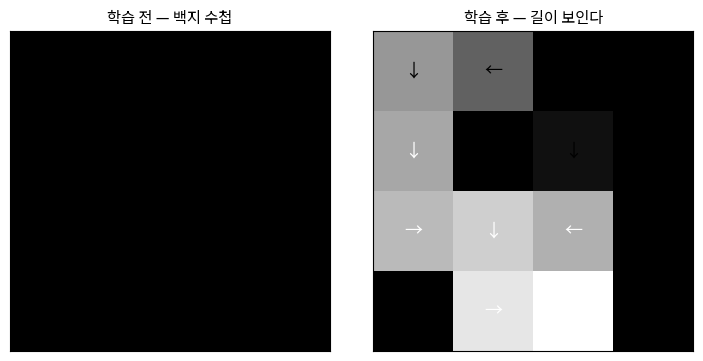

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.6))
viz.plot_qtable(Q_before, ax=axes[0],
                title="학습 전 — 백지 수첩")
viz.plot_qtable(Q_after, ax=axes[1],
                title="학습 후 — 길이 보인다")
plt.tight_layout()
plt.show()

**핵심 포인트**
- 밝을수록 가치가 높은 칸, 화살표는 그 칸의 최선 행동이다 — 목표에서 출발점 쪽으로 **가치가 번져 나간** 모양(γ의 할인 전파)을 확인하자.
- 화살표만 이으면 최단 경로가 된다 — Q-테이블이 곧 정책이다(13.3.1).
- 그리기 함수는 `utils/viz.py`(코드 정책 ③).

### [셀 5] ε=0.1 vs 0.9 — 탐험과 활용의 대가 📖

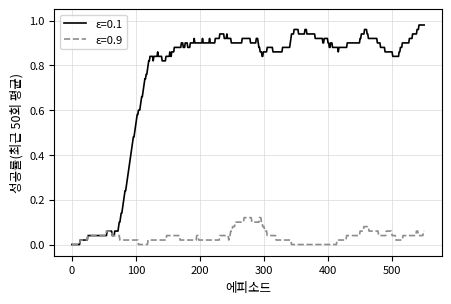

ε=0.1: 학습 후 탐욕 정책으로 성공 (6걸음)
ε=0.9: 학습 후 탐욕 정책으로 성공 (6걸음)


In [6]:
Q9, wins09 = q_learning(eps=0.9)

viz.plot_success_curves({"ε=0.1": wins01,
                         "ε=0.9": wins09})
plt.show()

for label, Qx in (("ε=0.1", Q_after), ("ε=0.9", Q9)):
    s, _ = env.reset(seed=0)
    done, steps, got = False, 0, 0.0
    while not done and steps < 100:
        s, r, term, trunc, _ = env.step(
            int(Qx[s].argmax()))
        done, steps, got = term or trunc, steps + 1, r
    print(f"{label}: 학습 후 탐욕 정책으로 "
          f"{'성공' if got else '실패'} ({steps}걸음)")

**핵심 포인트**(실행 검증 수치)
- **학습 중 성공률**: ε=0.1은 91% 수준까지 오르지만 ε=0.9는 5% 미만에 머문다 — 아는 길도 열에 아홉은 도박을 하니 당연하다.
- 그런데 **학습이 끝난 뒤 탐욕 정책은 둘 다 성공**한다(6걸음 최단) — 마구 돌아다닌 ε=0.9도 수첩(Q)은 제대로 채운 것이다.
- 교훈: 탐험은 "지식"을 만들고 활용은 "성과"를 만든다 — 학습 중 성과와 최종 정책의 품질은 별개다(13.3.3). 그래서 실전은 [심화 2]의 "처음엔 탐험, 갈수록 활용"(ε 감소)을 쓴다.

실패 시 대처: 성공률이 0에 머물면 [셀 3]의 동률 무작위 처리(`np.flatnonzero`)가 빠지지 않았는지 확인한다.

### [보조 2] 학습된 정책의 에피소드 재생 (텍스트 렌더)

In [7]:
env_txt = gym.make("FrozenLake-v1", map_name="4x4",
                   is_slippery=False,
                   render_mode="ansi")
s, _ = env_txt.reset(seed=0)
done, steps = False, 0
print(env_txt.render())
while not done and steps < 20:
    s, r, term, trunc, _ = env_txt.step(
        int(Q_after[s].argmax()))
    done, steps = term or trunc, steps + 1
    print(env_txt.render())
print(f"{steps}걸음 만에 도착" if r else "실패")


SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

6걸음 만에 도착


### [심화 1] α·γ·보상 변형 — 손계산 검산 슬롯 (연습문제 응용 직결)

In [8]:
# 연습문제 응용: "다른 조건으로 Q값 갱신 1~2스텝 계산"
# 문항을 손으로 푼 뒤, 아래에 같은 조건을 넣어 검산하자.
def one_update(Q_s_a, r, max_next, alpha, gamma):
    """갱신식 한 줄을 함수로 — 손계산 검산용."""
    return Q_s_a + alpha * (r + gamma * max_next - Q_s_a)

# 예: α=0.5, γ=0.8, 현재 Q=0.2, 보상 0, 다음 최댓값 0.5
print(f"{one_update(0.2, 0.0, 0.5, 0.5, 0.8):.3f}")
# TODO: 문제의 조건으로 바꿔 검산

0.300


### [심화 2] ε 감소 스케줄 + 미끄러운 호수 (연습문제 직결)

In [9]:
# TODO 1: 선형 감소 ε(1.0 → 0.05)로 q_learning을 고쳐
#         [셀 5] 곡선에 세 번째 선을 추가하자 —
#         "처음엔 탐험, 갈수록 활용"의 효과 확인.
# TODO 2: is_slippery=True(확률적 환경)로 바꾸면
#         600판으로 충분한가? 에피소드 수·α를 조절하며
#         결정적 환경과의 차이를 해석하자.
def eps_linear(ep, episodes, hi=1.0, lo=0.05):
    return hi + (lo - hi) * ep / (episodes - 1)

print([round(eps_linear(e, 600), 2)
       for e in (0, 150, 300, 450, 599)])

[1.0, 0.76, 0.52, 0.29, 0.05]


---
## 마무리

- Q-러닝의 전부는 갱신식 한 줄이다 — 손계산([셀 2])과 600판 학습([셀 3])이 같은 줄을 쓴다.
- Q-테이블 히트맵에서 가치가 목표로부터 번져 나오는 것(γ 전파)과, 화살표가 곧 정책임을 봤다.
- 탐험(지식)과 활용(성과)은 별개의 화폐다 — ε=0.9도 결국 길은 배웠다([셀 5]). 실전형 절충이 ε 감소 스케줄이다.

**연습문제 연계**: [응용] Q값 갱신 계산은 [심화 1]로 검산, [응용] ε 스케줄 비교는 [심화 2]에서 수행한다.

**다음 장**: 14장 — [실습 14-1] 공정성 지표 계산 (`ch14/lab-14-01_fairness-metrics.ipynb`)